# 04 · LZMA and ZSTD CodeCarbon benchmarks

This notebook is the **classical-compressor measurement notebook**. It does not
import or execute notebook 01 and it does not use Mamba or BOA's range coder.

It benchmarks standard LZMA and ZSTD on the same CMS source bytes and the same
input factors used by the BOA scaling experiment:

`1, 2, 4, 6, 8` × 49.92 MB ≈ **49.92, 99.84, 199.68, 299.52 and 399.36 MB**.

For every algorithm and input size, the notebook:

1. measures compression with a separate CodeCarbon tracker;
2. measures decompression with a separate CodeCarbon tracker;
3. verifies the lossless round trip using SHA-256;
4. records compressed size and compression ratio;
5. exports one long-format CSV for notebook 03.

LZMA and ZSTD have **no training stage**. The actual CodeCarbon location is
fixed to the United Kingdom (`GBR`) to match notebook 01. Notebook 03 converts
the measured energy into other electricity-region scenarios.


In [2]:
# Configuration shared conceptually with notebook 01.
CONFIG = {
    "data_url": (
        "https://raw.githubusercontent.com/AkkiG2401/boa-constrictor/"
        "main/experiments/cms_experiment/CMS_DATA_float32.bin"
    ),
    "expected_source_bytes": 49_920_000,
    "scaling_factors": [1, 2, 4, 6, 8],
    "lzma_preset": 6,       # Python/LZMA default-quality benchmark
    "zstd_level": 3,        # standard ZSTD default level
    "country_iso_code": "GBR",
    "plot_region_iso": "GBR",
    "project_folder_name": "BOA_carbon_project",
    "codecarbon_measure_power_secs": 1,
    # Fast codecs are repeated inside one tracker so CodeCarbon observes
    # several one-second samples. Reported metrics are divided by operations.
    "minimum_tracked_seconds": 8.0,
    "maximum_repeats": 20,
    "copy_buffer_bytes": 8 * 1024 * 1024,
}

if CONFIG["scaling_factors"] != sorted(set(CONFIG["scaling_factors"])):
    raise ValueError("scaling_factors must be unique and sorted.")
if CONFIG["scaling_factors"][0] != 1:
    raise ValueError("scaling_factors must start at 1.")
if CONFIG["minimum_tracked_seconds"] <= 0:
    raise ValueError("minimum_tracked_seconds must be positive.")
if CONFIG["maximum_repeats"] < 1:
    raise ValueError("maximum_repeats must be at least one.")

CONFIG


{'data_url': 'https://raw.githubusercontent.com/AkkiG2401/boa-constrictor/main/experiments/cms_experiment/CMS_DATA_float32.bin',
 'expected_source_bytes': 49920000,
 'scaling_factors': [1, 2, 4, 6, 8],
 'lzma_preset': 6,
 'zstd_level': 3,
 'country_iso_code': 'GBR',
 'plot_region_iso': 'GBR',
 'project_folder_name': 'BOA_carbon_project',
 'codecarbon_measure_power_secs': 1,
 'minimum_tracked_seconds': 8.0,
 'maximum_repeats': 20,
 'copy_buffer_bytes': 8388608}

In [3]:
# Colab dependencies. LZMA is part of Python's standard library.
%pip -q install "codecarbon>=3.2,<4" "pandas>=2.0" "zstandard>=0.22"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.0 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import csv
import hashlib
import json
import lzma
import math
import os
import shutil
import sys
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zstandard as zstd
from codecarbon import OfflineEmissionsTracker
from IPython.display import display


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    PROJECT_ROOT = (
        Path("/content/drive/MyDrive")
        / CONFIG["project_folder_name"]
    )
    TEMP_ROOT = Path("/content/classical_benchmark_tmp")
else:
    local_project = Path.cwd() / CONFIG["project_folder_name"]
    PROJECT_ROOT = (
        local_project if local_project.exists() else Path.cwd()
    )
    TEMP_ROOT = Path.cwd() / "classical_benchmark_tmp"

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RAW_CODECARBON_DIR = RESULTS_DIR / "classical_codecarbon_raw"
for directory in (DATA_DIR, RESULTS_DIR, RAW_CODECARBON_DIR, TEMP_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "CMS_DATA_float32.bin"
RESULTS_CSV = RESULTS_DIR / "classical_benchmark_measurements.csv"
RESULTS_JSON = RESULTS_DIR / "classical_benchmark_measurements.json"
SUMMARY_CSV = RESULTS_DIR / "classical_benchmark_summary.csv"
ALGORITHM_SUMMARY_CSV = RESULTS_DIR / "algorithm_carbon_summary.csv"
ALGORITHM_PLOT_PATH = RESULTS_DIR / "boa_lzma_zstd_carbon.png"
BOA_METRICS_PATH = RESULTS_DIR / "boa_metrics.json"
BOA_SCALING_PATH = RESULTS_DIR / "boa_scaling_measurements.csv"

print("Project root:", PROJECT_ROOT)
print("Temporary local work area:", TEMP_ROOT)
print("Results:", RESULTS_CSV)


Mounted at /content/drive
Project root: /content/drive/MyDrive/BOA_carbon_project
Temporary local work area: /content/classical_benchmark_tmp
Results: /content/drive/MyDrive/BOA_carbon_project/results/classical_benchmark_measurements.csv


In [5]:
def sha256_file(path, block_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            block = handle.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def make_repeated_file(source_path, destination_path, repeat_count):
    source_path = Path(source_path)
    destination_path = Path(destination_path)
    if repeat_count < 1:
        raise ValueError("repeat_count must be positive.")
    destination_path.unlink(missing_ok=True)
    with destination_path.open("wb") as destination:
        for _ in range(repeat_count):
            with source_path.open("rb") as source:
                shutil.copyfileobj(
                    source,
                    destination,
                    length=CONFIG["copy_buffer_bytes"],
                )
    expected = source_path.stat().st_size * repeat_count
    if destination_path.stat().st_size != expected:
        raise RuntimeError(
            f"Repeated-file size mismatch: expected {expected} bytes."
        )
    return destination_path


if not DATA_PATH.exists():
    print("Downloading CMS input...")
    urllib.request.urlretrieve(CONFIG["data_url"], DATA_PATH)

source_bytes = DATA_PATH.stat().st_size
if source_bytes != CONFIG["expected_source_bytes"]:
    raise RuntimeError(
        "Unexpected CMS source size: "
        f"expected {CONFIG['expected_source_bytes']}, found {source_bytes}."
    )

SOURCE_SHA256 = sha256_file(DATA_PATH)
print(f"CMS input: {source_bytes:,} bytes")
print("SHA-256:", SOURCE_SHA256)


CMS input: 49,920,000 bytes
SHA-256: edd6e4dd573acf7fb83b352726f5a23062572a5139cd268bd3dd9561d133dec6


In [6]:
def read_last_csv_row(path):
    with Path(path).open("r", newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise RuntimeError(f"CodeCarbon wrote no rows to {path}.")
    return rows[-1]


def float_or_none(value):
    if value in (None, ""):
        return None
    try:
        parsed = float(value)
    except (TypeError, ValueError):
        return None
    return parsed if math.isfinite(parsed) else None


def run_repeatedly(operation):
    # Run complete codec operations long enough for stable sampling.
    start = time.perf_counter()
    operations = 0
    while True:
        operation()
        operations += 1
        elapsed = time.perf_counter() - start
        if elapsed >= CONFIG["minimum_tracked_seconds"]:
            break
        if operations >= CONFIG["maximum_repeats"]:
            break
    return operations


def measure_operation(stage_name, operation):
    output_file = f"codecarbon_{stage_name}.csv"
    output_path = RAW_CODECARBON_DIR / output_file
    output_path.unlink(missing_ok=True)

    tracker = OfflineEmissionsTracker(
        project_name=f"classical_{stage_name}",
        country_iso_code=CONFIG["country_iso_code"],
        output_dir=str(RAW_CODECARBON_DIR),
        output_file=output_file,
        measure_power_secs=CONFIG["codecarbon_measure_power_secs"],
        tracking_mode="machine",
        save_to_file=True,
        save_to_api=False,
        log_level="warning",
    )

    tracker.start()
    start = time.perf_counter()
    try:
        operations = run_repeatedly(operation)
        tracked_runtime_s = time.perf_counter() - start
    except Exception:
        tracker.stop()
        raise
    emissions_from_stop = tracker.stop()

    row = read_last_csv_row(output_path)
    reported_country = row.get("country_iso_code")
    if reported_country != CONFIG["country_iso_code"]:
        raise RuntimeError(
            f"CodeCarbon country mismatch for {stage_name}: "
            f"{reported_country!r}."
        )

    total_emissions = float_or_none(row.get("emissions"))
    if total_emissions is None:
        total_emissions = float_or_none(emissions_from_stop)
    if total_emissions is None:
        raise RuntimeError(f"Missing emissions measurement for {stage_name}.")
    total_energy = float_or_none(row.get("energy_consumed"))
    if total_energy is None:
        raise RuntimeError(f"Missing energy measurement for {stage_name}.")

    metrics = {
        "operations": int(operations),
        "tracked_runtime_s": float(tracked_runtime_s),
        "runtime_s": float(tracked_runtime_s / operations),
        "energy_kWh": float(total_energy / operations),
        "emissions_kgCO2eq": float(total_emissions / operations),
        "cpu_energy_kWh": (
            float_or_none(row.get("cpu_energy")) / operations
            if float_or_none(row.get("cpu_energy")) is not None
            else None
        ),
        "gpu_energy_kWh": (
            float_or_none(row.get("gpu_energy")) / operations
            if float_or_none(row.get("gpu_energy")) is not None
            else None
        ),
        "ram_energy_kWh": (
            float_or_none(row.get("ram_energy")) / operations
            if float_or_none(row.get("ram_energy")) is not None
            else None
        ),
        "country_iso_code": reported_country,
        "country_name": row.get("country_name") or None,
        "codecarbon_csv": str(output_path),
    }
    print(
        f"[{stage_name}] operations={operations} | "
        f"runtime/op={metrics['runtime_s']:.4f}s | "
        f"energy/op={metrics['energy_kWh']:.6e} kWh | "
        f"emissions/op={metrics['emissions_kgCO2eq']:.6e} kgCO2eq"
    )
    return metrics


In [7]:
def lzma_compress(input_path, compressed_path):
    with Path(input_path).open("rb") as source:
        with lzma.open(
            compressed_path,
            "wb",
            format=lzma.FORMAT_XZ,
            preset=CONFIG["lzma_preset"],
        ) as destination:
            shutil.copyfileobj(
                source,
                destination,
                length=CONFIG["copy_buffer_bytes"],
            )


def lzma_decompress(compressed_path, restored_path):
    with lzma.open(compressed_path, "rb") as source:
        with Path(restored_path).open("wb") as destination:
            shutil.copyfileobj(
                source,
                destination,
                length=CONFIG["copy_buffer_bytes"],
            )


def zstd_compress(input_path, compressed_path):
    compressor = zstd.ZstdCompressor(
        level=CONFIG["zstd_level"],
        threads=0,
        write_checksum=True,
    )
    with Path(input_path).open("rb") as source:
        with Path(compressed_path).open("wb") as destination:
            compressor.copy_stream(
                source,
                destination,
                read_size=CONFIG["copy_buffer_bytes"],
                write_size=CONFIG["copy_buffer_bytes"],
            )


def zstd_decompress(compressed_path, restored_path):
    decompressor = zstd.ZstdDecompressor()
    with Path(compressed_path).open("rb") as source:
        with Path(restored_path).open("wb") as destination:
            decompressor.copy_stream(
                source,
                destination,
                read_size=CONFIG["copy_buffer_bytes"],
                write_size=CONFIG["copy_buffer_bytes"],
            )


ALGORITHMS = {
    "lzma": {
        "level": f"preset={CONFIG['lzma_preset']}",
        "suffix": ".xz",
        "compress": lzma_compress,
        "decompress": lzma_decompress,
    },
    "zstd": {
        "level": f"level={CONFIG['zstd_level']}",
        "suffix": ".zst",
        "compress": zstd_compress,
        "decompress": zstd_decompress,
    },
}


In [8]:
benchmark_rows = []

for factor in CONFIG["scaling_factors"]:
    temporary_input = factor != 1
    if temporary_input:
        input_path = TEMP_ROOT / f"cms_input_{factor}x.bin"
        make_repeated_file(DATA_PATH, input_path, factor)
    else:
        input_path = DATA_PATH

    input_bytes = input_path.stat().st_size
    input_MB = input_bytes / 1_000_000.0
    input_hash = sha256_file(input_path)
    print(f"\n=== {factor}x: {input_MB:.2f} MB ===")

    for algorithm, specification in ALGORITHMS.items():
        compressed_path = (
            TEMP_ROOT
            / f"cms_{factor}x{specification['suffix']}"
        )
        restored_path = (
            TEMP_ROOT
            / f"cms_{factor}x_{algorithm}_restored.bin"
        )
        compressed_path.unlink(missing_ok=True)
        restored_path.unlink(missing_ok=True)

        def compression_operation():
            specification["compress"](input_path, compressed_path)

        compression_metrics = measure_operation(
            f"{algorithm}_compression_{factor}x",
            compression_operation,
        )
        compressed_bytes = compressed_path.stat().st_size

        def decompression_operation():
            specification["decompress"](
                compressed_path,
                restored_path,
            )

        decompression_metrics = measure_operation(
            f"{algorithm}_decompression_{factor}x",
            decompression_operation,
        )

        restored_hash = sha256_file(restored_path)
        roundtrip_ok = (
            restored_hash == input_hash
            and restored_path.stat().st_size == input_bytes
        )
        if not roundtrip_ok:
            raise RuntimeError(
                f"{algorithm} {factor}x lossless round trip failed."
            )

        common = {
            "algorithm": algorithm,
            "codec_setting": specification["level"],
            "factor": int(factor),
            "input_bytes": int(input_bytes),
            "input_MB": float(input_MB),
            "input_sha256": input_hash,
            "compressed_bytes": int(compressed_bytes),
            "compressed_MB": compressed_bytes / 1_000_000.0,
            "compression_ratio": input_bytes / compressed_bytes,
            "roundtrip_ok": True,
            "has_training": False,
        }
        for stage, metrics in (
            ("compression", compression_metrics),
            ("decompression", decompression_metrics),
        ):
            benchmark_rows.append(
                {
                    **common,
                    "stage": stage,
                    **metrics,
                }
            )

        print(
            f"{algorithm.upper()}: "
            f"{compressed_bytes:,} bytes, "
            f"ratio={input_bytes / compressed_bytes:.4f}x, "
            "lossless=True"
        )
        compressed_path.unlink(missing_ok=True)
        restored_path.unlink(missing_ok=True)

    if temporary_input:
        input_path.unlink(missing_ok=True)


CLASSICAL_BENCHMARKS = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["algorithm", "factor", "stage"])
    .reset_index(drop=True)
)

if not CLASSICAL_BENCHMARKS["roundtrip_ok"].all():
    raise RuntimeError("At least one classical benchmark failed.")


[codecarbon INFO @ 13:47:05] offline tracker init
[codecarbon WARNING @ 13:47:05] Multiple instances of codecarbon are allowed to run at the same time.



=== 1x: 49.92 MB ===


[codecarbon WARNING @ 13:47:07] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 13:47:07] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 13:47:07] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon WARNING @ 13:47:07] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon WARNING @ 13:47:51] Multiple instances of codecarbon are allowed to run at the same time.


[lzma_compression_1x] operations=1 | runtime/op=44.0799s | energy/op=3.040122e-04 kWh | emissions/op=7.222996e-05 kgCO2eq


[codecarbon WARNING @ 13:48:00] Multiple instances of codecarbon are allowed to run at the same time.


...

[lzma_compression_8x] operations=1 | runtime/op=293.0656s | energy/op=1.936443e-03 kWh | emissions/op=4.600775e-04 kgCO2eq
[lzma_decompression_8x] operations=1 | runtime/op=11.6348s | energy/op=7.479878e-05 kWh | emissions/op=1.777137e-05 kgCO2eq


[codecarbon WARNING @ 14:02:36] Multiple instances of codecarbon are allowed to run at the same time.


LZMA: 123,077,140 bytes, ratio=3.2448x, lossless=True


[codecarbon WARNING @ 14:02:44] Multiple instances of codecarbon are allowed to run at the same time.


[zstd_compression_8x] operations=2 | runtime/op=4.2568s | energy/op=2.872887e-05 kWh | emissions/op=6.825662e-06 kgCO2eq
[zstd_decompression_8x] operations=5 | runtime/op=1.9390s | energy/op=1.330077e-05 kWh | emissions/op=3.160117e-06 kgCO2eq
ZSTD: 160,073,439 bytes, ratio=2.4949x, lossless=True


In [9]:
CLASSICAL_BENCHMARKS.to_csv(RESULTS_CSV, index=False)
json_records = (
    CLASSICAL_BENCHMARKS.astype(object)
    .where(pd.notna(CLASSICAL_BENCHMARKS), None)
    .to_dict(orient="records")
)
RESULTS_JSON.write_text(
    json.dumps(
        json_records,
        indent=2,
        allow_nan=False,
    ),
    encoding="utf-8",
)

CLASSICAL_SUMMARY = (
    CLASSICAL_BENCHMARKS.pivot_table(
        index=[
            "algorithm",
            "codec_setting",
            "factor",
            "input_MB",
            "compressed_MB",
            "compression_ratio",
            "roundtrip_ok",
        ],
        columns="stage",
        values=[
            "runtime_s",
            "energy_kWh",
            "emissions_kgCO2eq",
            "operations",
        ],
        aggfunc="first",
    )
    .reset_index()
)
CLASSICAL_SUMMARY.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else str(column)
    for column in CLASSICAL_SUMMARY.columns
]
CLASSICAL_SUMMARY.to_csv(SUMMARY_CSV, index=False)

display(
    CLASSICAL_BENCHMARKS[
        [
            "algorithm",
            "codec_setting",
            "factor",
            "input_MB",
            "stage",
            "runtime_s",
            "energy_kWh",
            "emissions_kgCO2eq",
            "compression_ratio",
            "operations",
            "roundtrip_ok",
        ]
    ]
)

print("Saved:", RESULTS_CSV)
print("Saved:", RESULTS_JSON)
print("Saved:", SUMMARY_CSV)


,algorithm,codec_setting,factor,input_MB,stage,runtime_s,energy_kWh,emissions_kgCO2eq,compression_ratio,operations,roundtrip_ok
0,lzma,preset=6,1,49.92,compression,44.079933,0.000304,7.222996e-05,3.240119,1,True
1,lzma,preset=6,1,49.92,decompression,1.397948,0.000009,2.225758e-06,3.240119,6,True
2,lzma,preset=6,2,99.84,compression,77.884470,0.000503,1.195772e-04,3.242757,1,True
3,lzma,preset=6,2,99.84,decompression,3.108155,0.000020,4.762175e-06,3.242757,3,True
4,lzma,preset=6,4,199.68,compression,153.297724,0.000998,2.371394e-04,3.244103,1,True
5,lzma,preset=6,4,199.68,decompression,5.726513,0.000037,8.714448e-06,3.244103,2,True
6,lzma,preset=6,6,299.52,compression,225.868137,0.001506,3.577722e-04,3.244556,1,True
7,lzma,preset=6,6,299.52,decompression,8.910605,0.000059,1.400892e-05,3.244556,1,True
8,lzma,preset=6,8,399.36,compression,293.065578,0.001936,4.600775e-04,3.244794,1,True
9,lzma,preset=6,8,399.36,decompression,11.634816,0.000075,1.777137e-05,3.244794,1,True


Saved: /content/drive/MyDrive/BOA_carbon_project/results/classical_benchmark_measurements.csv
Saved: /content/drive/MyDrive/BOA_carbon_project/results/classical_benchmark_measurements.json
Saved: /content/drive/MyDrive/BOA_carbon_project/results/classical_benchmark_summary.csv


## BOA, LZMA and ZSTD comparison

This section completes the fourth task inside notebook 04. It reads the
measurement files exported by notebook 01; it does **not** execute notebook 01.

All three algorithms are compared at identical raw input sizes and under one
common electricity-region factor. The baseline assumes:

- BOA: full canonical training + compression + one decompression;
- LZMA and ZSTD: compression + one decompression, with no training.

For each measured stage, the energy model is a through-origin fit:

$$
\widehat{\beta}_s =
\frac{\sum_i D_i E_{s,i}}{\sum_i D_i^2},
\qquad
\widehat{C}_{s,r}(D)=D\widehat{\beta}_s I_r.
$$

The one-epoch BOA scaling measurements test inference linearity; BOA's total
line uses the complete canonical training energy from `boa_metrics.json`.


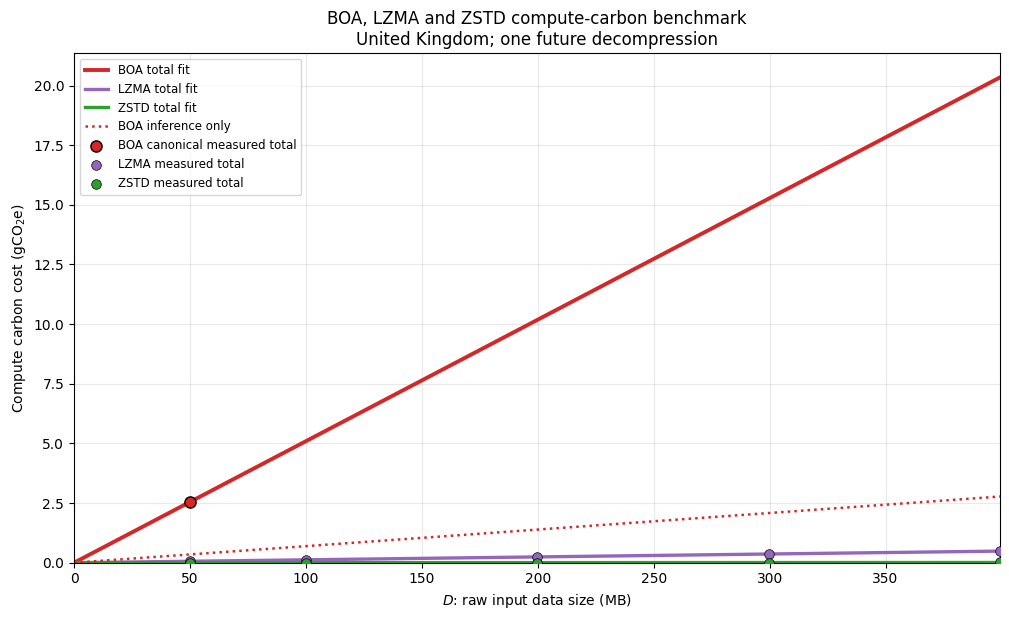

,algorithm,energy_kWh_per_MB,region_iso,gCO2e_per_kWh,gCO2e_per_MB,training_included,future_decompressions
0,BOA,2.143781e-04,GBR,237.589,0.050934,True,1
1,LZMA,5.128533e-06,GBR,237.589,0.001218,False,1
2,ZSTD,9.906127e-08,GBR,237.589,0.000024,False,1


Saved: /content/drive/MyDrive/BOA_carbon_project/results/boa_lzma_zstd_carbon.png
Saved: /content/drive/MyDrive/BOA_carbon_project/results/algorithm_carbon_summary.csv


In [10]:
REGION_INTENSITY_GCO2E_PER_KWH = {
    "GBR": 237.589,
    "CHE": 34.843,
    "SWE": 40.695,
    "DEU": 380.950,
}
REGION_NAMES = {
    "GBR": "United Kingdom",
    "CHE": "Switzerland",
    "SWE": "Sweden",
    "DEU": "Germany",
}
EXPECTED_DECOMPRESSIONS = 1

missing_boa = [
    path
    for path in (BOA_METRICS_PATH, BOA_SCALING_PATH)
    if not path.exists()
]
if missing_boa:
    formatted = "\n".join(f"  - {path}" for path in missing_boa)
    raise FileNotFoundError(
        "Notebook 04 needs the exported measurements from notebook 01, "
        "but does not run notebook 01.\n"
        f"Missing:\n{formatted}"
    )

with BOA_METRICS_PATH.open("r", encoding="utf-8") as handle:
    BOA_METRICS = json.load(handle)
BOA_SCALING = pd.read_csv(BOA_SCALING_PATH)

required_boa_columns = {"input_MB", "stage", "energy_kWh"}
missing_boa_columns = required_boa_columns - set(BOA_SCALING.columns)
if missing_boa_columns:
    raise KeyError(
        "boa_scaling_measurements.csv is missing columns: "
        f"{sorted(missing_boa_columns)}"
    )

required_classical_columns = {
    "algorithm",
    "input_MB",
    "stage",
    "energy_kWh",
    "country_iso_code",
    "roundtrip_ok",
    "has_training",
}
missing_classical_columns = (
    required_classical_columns - set(CLASSICAL_BENCHMARKS.columns)
)
if missing_classical_columns:
    raise KeyError(
        "Classical results are missing columns: "
        f"{sorted(missing_classical_columns)}"
    )

if set(CLASSICAL_BENCHMARKS["algorithm"]) != {"lzma", "zstd"}:
    raise ValueError("Expected exactly LZMA and ZSTD measurements.")
if set(CLASSICAL_BENCHMARKS["stage"]) != {
    "compression",
    "decompression",
}:
    raise ValueError(
        "LZMA/ZSTD must contain compression and decompression only."
    )
if not (
    CLASSICAL_BENCHMARKS["roundtrip_ok"]
    .astype(str)
    .str.lower()
    .eq("true")
    .all()
):
    raise RuntimeError("A classical lossless round-trip check failed.")
if (
    CLASSICAL_BENCHMARKS["has_training"]
    .astype(str)
    .str.lower()
    .eq("true")
    .any()
):
    raise ValueError("LZMA and ZSTD must not contain training.")
if set(CLASSICAL_BENCHMARKS["country_iso_code"]) != {
    CONFIG["country_iso_code"]
}:
    raise ValueError("Classical measurements use an inconsistent region.")

boa_sizes = np.sort(BOA_SCALING["input_MB"].dropna().unique())
classical_sizes = np.sort(
    CLASSICAL_BENCHMARKS["input_MB"].dropna().unique()
)
if (
    len(boa_sizes) != len(classical_sizes)
    or not np.allclose(boa_sizes, classical_sizes, rtol=0, atol=1e-9)
):
    raise ValueError(
        "BOA, LZMA and ZSTD must use exactly the same input sizes."
    )


def through_origin_slope(frame):
    x = frame["input_MB"].to_numpy(dtype=float)
    y = frame["energy_kWh"].to_numpy(dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y >= 0)
    x = x[valid]
    y = y[valid]
    if len(x) < 2:
        raise ValueError("At least two finite points are needed for a fit.")
    return float(np.dot(x, y) / np.dot(x, x))


boa_stage_slopes = {}
for stage in ("compression", "decompression"):
    frame = BOA_SCALING.loc[
        BOA_SCALING["stage"] == stage,
        ["input_MB", "energy_kWh"],
    ]
    boa_stage_slopes[stage] = through_origin_slope(frame)

classical_stage_slopes = {}
for algorithm in ("lzma", "zstd"):
    for stage in ("compression", "decompression"):
        frame = CLASSICAL_BENCHMARKS.loc[
            (CLASSICAL_BENCHMARKS["algorithm"] == algorithm)
            & (CLASSICAL_BENCHMARKS["stage"] == stage),
            ["input_MB", "energy_kWh"],
        ]
        classical_stage_slopes[(algorithm, stage)] = (
            through_origin_slope(frame)
        )

boa_training_slope = (
    float(BOA_METRICS["training_energy_kWh"])
    / float(BOA_METRICS["input_MB"])
)
boa_inference_slope = (
    boa_stage_slopes["compression"]
    + EXPECTED_DECOMPRESSIONS
    * boa_stage_slopes["decompression"]
)
energy_slopes = {
    "BOA": boa_training_slope + boa_inference_slope,
    "LZMA": (
        classical_stage_slopes[("lzma", "compression")]
        + EXPECTED_DECOMPRESSIONS
        * classical_stage_slopes[("lzma", "decompression")]
    ),
    "ZSTD": (
        classical_stage_slopes[("zstd", "compression")]
        + EXPECTED_DECOMPRESSIONS
        * classical_stage_slopes[("zstd", "decompression")]
    ),
}

region_iso = CONFIG["plot_region_iso"]
if region_iso not in REGION_INTENSITY_GCO2E_PER_KWH:
    raise ValueError(f"Unknown plot_region_iso: {region_iso}")
intensity = REGION_INTENSITY_GCO2E_PER_KWH[region_iso]

D = np.linspace(0.0, float(classical_sizes.max()), 300)
styles = {
    "BOA": {"color": "#d62728", "linewidth": 2.8},
    "LZMA": {"color": "#9467bd", "linewidth": 2.4},
    "ZSTD": {"color": "#2ca02c", "linewidth": 2.4},
}

fig, ax = plt.subplots(figsize=(10.2, 6.3))
for algorithm, slope in energy_slopes.items():
    ax.plot(
        D,
        D * slope * intensity,
        label=f"{algorithm} total fit",
        **styles[algorithm],
    )

ax.plot(
    D,
    D * boa_inference_slope * intensity,
    color=styles["BOA"]["color"],
    linestyle=":",
    linewidth=1.8,
    label="BOA inference only",
)

boa_measured_total_kWh = (
    float(BOA_METRICS["training_energy_kWh"])
    + float(BOA_METRICS["compression_energy_kWh"])
    + EXPECTED_DECOMPRESSIONS
    * float(BOA_METRICS["decompression_energy_kWh"])
)
ax.scatter(
    [float(BOA_METRICS["input_MB"])],
    [boa_measured_total_kWh * intensity],
    color=styles["BOA"]["color"],
    edgecolor="black",
    s=65,
    zorder=5,
    label="BOA canonical measured total",
)

for algorithm in ("lzma", "zstd"):
    measured = (
        CLASSICAL_BENCHMARKS.loc[
            CLASSICAL_BENCHMARKS["algorithm"] == algorithm
        ]
        .pivot_table(
            index="input_MB",
            columns="stage",
            values="energy_kWh",
            aggfunc="first",
        )
        .reset_index()
        .sort_values("input_MB")
    )
    total = (
        measured["compression"]
        + EXPECTED_DECOMPRESSIONS * measured["decompression"]
    )
    ax.scatter(
        measured["input_MB"],
        total * intensity,
        color=styles[algorithm.upper()]["color"],
        edgecolor="black",
        linewidth=0.5,
        s=48,
        zorder=5,
        label=f"{algorithm.upper()} measured total",
    )

ax.set_xlabel(r"$D$: raw input data size (MB)")
ax.set_ylabel(r"Compute carbon cost (gCO$_2$e)")
ax.set_title(
    "BOA, LZMA and ZSTD compute-carbon benchmark\n"
    f"{REGION_NAMES[region_iso]}; one future decompression"
)
ax.set_xlim(0, float(classical_sizes.max()))
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.28)
ax.legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(ALGORITHM_PLOT_PATH, dpi=180, bbox_inches="tight")
plt.show()

ALGORITHM_SUMMARY = pd.DataFrame(
    [
        {
            "algorithm": algorithm,
            "energy_kWh_per_MB": slope,
            "region_iso": region_iso,
            "gCO2e_per_kWh": intensity,
            "gCO2e_per_MB": slope * intensity,
            "training_included": algorithm == "BOA",
            "future_decompressions": EXPECTED_DECOMPRESSIONS,
        }
        for algorithm, slope in energy_slopes.items()
    ]
)
ALGORITHM_SUMMARY.to_csv(ALGORITHM_SUMMARY_CSV, index=False)
display(ALGORITHM_SUMMARY)
print("Saved:", ALGORITHM_PLOT_PATH)
print("Saved:", ALGORITHM_SUMMARY_CSV)


## Output contract and limitations

Notebook 04 writes:

- `results/classical_benchmark_measurements.csv`;
- `results/algorithm_carbon_summary.csv`;
- `results/boa_lzma_zstd_carbon.png`.

The comparison section reads notebook 01's exported JSON/CSV files, without executing notebook 01.

The CSV reports **per-operation** energy and carbon. If a codec completes too
quickly for stable one-second CodeCarbon sampling, the complete operation is
repeated inside one tracker and the total is divided by the recorded operation
count.

Important boundaries:

1. LZMA and ZSTD are standard independent compressors; neither uses Mamba.
2. `tracking_mode="machine"` matches notebook 01's system boundary. On a
   GPU-enabled Colab machine, a CPU codec may therefore include idle-GPU
   machine energy.
3. The first benchmark uses repeated copies of one CMS file. Different-file
   validation remains a separate experiment.
4. Codec levels are explicit but are not mathematically equivalent:
   LZMA preset 6 and ZSTD level 3 are common defaults.
5. These measurements compare compute carbon. Net storage benefit additionally
   requires the compressed storage volume, retention period and read policy.


In [11]:
# ============================================================
# Compression-ratio comparison: BOA, LZMA and ZSTD
# ============================================================

required_boa_ratio_columns = {
    "input_MB",
    "stage",
    "ratio_excl_model",
    "ratio_incl_one_shared_model",
}

missing_boa_ratio_columns = (
    required_boa_ratio_columns - set(BOA_SCALING.columns)
)

if missing_boa_ratio_columns:
    raise KeyError(
        "BOA_SCALING is missing compression-ratio columns: "
        f"{sorted(missing_boa_ratio_columns)}"
    )

required_classical_ratio_columns = {
    "algorithm",
    "input_MB",
    "stage",
    "compression_ratio",
}

missing_classical_ratio_columns = (
    required_classical_ratio_columns
    - set(CLASSICAL_BENCHMARKS.columns)
)

if missing_classical_ratio_columns:
    raise KeyError(
        "CLASSICAL_BENCHMARKS is missing compression-ratio columns: "
        f"{sorted(missing_classical_ratio_columns)}"
    )


# BOA has the same ratio repeated for training, compression and
# decompression rows, so retain only the compression row.
boa_ratio_by_size = (
    BOA_SCALING.loc[
        BOA_SCALING["stage"] == "compression",
        [
            "input_MB",
            "ratio_excl_model",
            "ratio_incl_one_shared_model",
        ],
    ]
    .drop_duplicates(subset=["input_MB"])
    .rename(
        columns={
            "ratio_excl_model": "BOA_payload_ratio",
            "ratio_incl_one_shared_model": (
                "BOA_ratio_including_one_shared_model"
            ),
        }
    )
)


# LZMA and ZSTD also repeat the ratio in the decompression rows.
# Retain the compression rows and pivot algorithms into columns.
classical_ratio_by_size = (
    CLASSICAL_BENCHMARKS.loc[
        CLASSICAL_BENCHMARKS["stage"] == "compression",
        [
            "algorithm",
            "input_MB",
            "compression_ratio",
        ],
    ]
    .drop_duplicates(
        subset=["algorithm", "input_MB"]
    )
    .pivot(
        index="input_MB",
        columns="algorithm",
        values="compression_ratio",
    )
    .reset_index()
    .rename(
        columns={
            "lzma": "LZMA_ratio",
            "zstd": "ZSTD_ratio",
        }
    )
)


COMPRESSION_RATIO_BY_SIZE = (
    boa_ratio_by_size
    .merge(
        classical_ratio_by_size,
        on="input_MB",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("input_MB")
    .reset_index(drop=True)
)


# Confirm that all algorithms were evaluated at the same input sizes.
if len(COMPRESSION_RATIO_BY_SIZE) != len(boa_ratio_by_size):
    raise ValueError(
        "BOA, LZMA and ZSTD compression ratios do not cover "
        "the same set of input sizes."
    )


print("Compression ratio by input size")
print("Ratio = raw input size / compressed size")

display(
    COMPRESSION_RATIO_BY_SIZE.style.format(
        {
            "input_MB": "{:,.2f}",
            "BOA_payload_ratio": "{:.6f}",
            "BOA_ratio_including_one_shared_model": "{:.6f}",
            "LZMA_ratio": "{:.6f}",
            "ZSTD_ratio": "{:.6f}",
        }
    )
)


# ============================================================
# Canonical 49.92 MB comparison for the slides
# ============================================================

canonical_input_MB = float(BOA_METRICS["input_MB"])

canonical_candidates = COMPRESSION_RATIO_BY_SIZE.loc[
    np.isclose(
        COMPRESSION_RATIO_BY_SIZE["input_MB"],
        canonical_input_MB,
        rtol=0.0,
        atol=1e-9,
    )
]

if len(canonical_candidates) != 1:
    raise ValueError(
        "Could not identify exactly one canonical BOA input-size row "
        f"at {canonical_input_MB:.2f} MB."
    )

canonical_row = canonical_candidates.iloc[0]

COMPRESSION_RATIO_SUMMARY = pd.DataFrame(
    [
        {
            "algorithm": "BOA",
            "input_MB": canonical_input_MB,
            "compression_ratio": canonical_row[
                "BOA_payload_ratio"
            ],
            "definition": "payload only",
        },
        {
            "algorithm": "LZMA",
            "input_MB": canonical_input_MB,
            "compression_ratio": canonical_row[
                "LZMA_ratio"
            ],
            "definition": "compressed file",
        },
        {
            "algorithm": "ZSTD",
            "input_MB": canonical_input_MB,
            "compression_ratio": canonical_row[
                "ZSTD_ratio"
            ],
            "definition": "compressed file",
        },
    ]
)


print(
    f"\nCanonical comparison at {canonical_input_MB:.2f} MB"
)

display(
    COMPRESSION_RATIO_SUMMARY.style.format(
        {
            "input_MB": "{:,.2f}",
            "compression_ratio": "{:.6f}",
        }
    )
)

print(
    "\nBOA ratio including one shared model: "
    f"{canonical_row['BOA_ratio_including_one_shared_model']:.6f}x"
)


# Optional CSV for the plotting notebook or slides.
COMPRESSION_RATIO_CSV = (
    RESULTS_DIR / "boa_lzma_zstd_compression_ratios.csv"
)

COMPRESSION_RATIO_BY_SIZE.to_csv(
    COMPRESSION_RATIO_CSV,
    index=False,
)

print("\nSaved:", COMPRESSION_RATIO_CSV)

Compression ratio by input size
Ratio = raw input size / compressed size


,input_MB,BOA_payload_ratio,BOA_ratio_including_one_shared_model,LZMA_ratio,ZSTD_ratio
0,49.92,3.724705,3.542232,3.240119,2.495073
1,99.84,3.724711,3.631183,3.242757,2.494947
2,199.68,3.724717,3.677358,3.244103,2.494872
3,299.52,3.724719,3.693012,3.244556,2.494868
4,399.36,3.724719,3.700888,3.244794,2.494855



Canonical comparison at 49.92 MB


,algorithm,input_MB,compression_ratio,definition
0,BOA,49.92,3.724705,payload only
1,LZMA,49.92,3.240119,compressed file
2,ZSTD,49.92,2.495073,compressed file



BOA ratio including one shared model: 3.542232x

Saved: /content/drive/MyDrive/BOA_carbon_project/results/boa_lzma_zstd_compression_ratios.csv
